In [4]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

In [12]:
from langgraph.graph import StateGraph, END
from agent.state import AgentState

from agent.nodes import (
    planner_node,
    retrieval_node,
    sql_node,
    reasoning_node,
)

def build_test_graph():

    graph = StateGraph(AgentState)

    graph.add_node("retrieval", retrieval_node)
    graph.add_node("planner", planner_node)
    graph.add_node("sql", sql_node)
    graph.add_node("reasoning", reasoning_node)

    graph.set_entry_point("retrieval")

    graph.add_edge("retrieval", "planner")
    graph.add_edge("planner", "sql")
    graph.add_edge("sql", "reasoning")
    graph.add_edge("reasoning", END)

    return graph.compile()


🧠 Schema changed — rebuilding entity FAISS index...
✅ Entity FAISS index rebuilt


In [15]:
from retrievers.schema_retriever import retrieve_relevant_entities

query = "Show me the top 5 products by revenue"

entities = retrieve_relevant_entities(query)

print(f"Retrieved {len(entities)} entities\n")

for entity in entities:
    print("=" * 80)
    print(entity)

Retrieved 25 entities

{'entity': 'products.cost_price', 'table': 'products', 'column': 'cost_price', 'type': 'float', 'text': 'table: products\n\ncolumn: cost_price\n\ntype: float\n\nprimary key: False\n\nforeign key: False\n\nsample values:'}
{'entity': 'products.unit_price', 'table': 'products', 'column': 'unit_price', 'type': 'float', 'text': 'table: products\n\ncolumn: unit_price\n\ntype: float\n\nprimary key: False\n\nforeign key: False\n\nsample values:'}
{'entity': 'products.product_name', 'table': 'products', 'column': 'product_name', 'type': 'varchar', 'text': 'table: products\n\ncolumn: product_name\n\ntype: varchar\n\nprimary key: False\n\nforeign key: False\n\nsample values:\nSofa 1\nJacket 2\nJacket 3\nLaptop 4\nTable 5'}
{'entity': 'products.category', 'table': 'products', 'column': 'category', 'type': 'varchar', 'text': 'table: products\n\ncolumn: category\n\ntype: varchar\n\nprimary key: False\n\nforeign key: False\n\nsample values:\nHome\nFashion\nElectronics'}
{'enti

In [16]:
from retrievers.graph_retriever import find_join_paths

graph_context = find_join_paths(entities)

print("TABLES:")
print(graph_context.get("tables"))

print("\nJOINS:")
for join in graph_context.get("joins", []):
    print(join)

TABLES:
['sales', 'customers', 'marketing_sales', 'products']

JOINS:
{'source_table': 'sales', 'source_column': 'customer_id', 'source_node': 'sales.customer_id', 'source_is_fk': True, 'target_table': 'customers', 'target_column': 'customer_id', 'target_node': 'customers.customer_id', 'target_is_pk': True, 'relationship': 'FOREIGN_KEY', 'relationship_type': 'many-to-one', 'join_condition': 'sales.customer_id = customers.customer_id'}
{'source_table': 'sales', 'source_column': 'product_id', 'source_node': 'sales.product_id', 'source_is_fk': True, 'target_table': 'products', 'target_column': 'product_id', 'target_node': 'products.product_id', 'target_is_pk': True, 'relationship': 'FOREIGN_KEY', 'relationship_type': 'many-to-one', 'join_condition': 'sales.product_id = products.product_id'}


In [18]:
from agent.nodes.retrieval_node import retrieval_node
state = {
    "query": "Show me the top 5 products by revenue"
}

retrieved_state = retrieval_node(state)

print("\nReturned state keys:")
print(retrieved_state.keys())


📚 STEP: Semantic Retrieval

📚 Retrieved Entities:

products.cost_price
products.unit_price
products.product_name
products.category
products.brand
products.product_id
sales.tax_percent
sales.product_id
products.sub_category
marketing_sales.TV
marketing_sales.Influencer
sales.discount_percent
sales.rating
sales.quantity
marketing_sales.Radio
marketing_sales.Sales
sales.sales_channel
sales.shipping_cost
marketing_sales.Social Media
customers.customer_segment
sales.sale_date
sales.sale_id
sales.returned
sales.delivery_days
customers.city

🔗 Graph Join Paths:

sales.customer_id = customers.customer_id
sales.product_id = products.product_id

🔎 Value Validation:

{'matched': [], 'missing': [], 'suggestions': {}}

✅ Validation Passed

Returned state keys:
dict_keys(['query', 'retrieved_entities', 'joins', 'graph_tables', 'value_validation'])


In [19]:
print("GRAPH TABLES:")
for table in retrieved_state.get("graph_tables", []):
    print("  ", table)

print("\nGRAPH JOINS:")
for join in retrieved_state.get("joins", []):
    print("=" * 80)
    print("Join condition:", join.get("join_condition"))
    print("Relationship:", join.get("relationship_type"))
    print("FK:", f"{join.get('source_table')}.{join.get('source_column')}")
    print("PK:", f"{join.get('target_table')}.{join.get('target_column')}")

GRAPH TABLES:
   sales
   customers
   marketing_sales
   products

GRAPH JOINS:
Join condition: sales.customer_id = customers.customer_id
Relationship: many-to-one
FK: sales.customer_id
PK: customers.customer_id
Join condition: sales.product_id = products.product_id
Relationship: many-to-one
FK: sales.product_id
PK: products.product_id


In [21]:
from agent.nodes.planner_node import planner_node
from agent.nodes.retrieval_node import retrieval_node
from agent.nodes.sql_node import sql_node
from agent.nodes.reasoning_node import reasoning_node

In [22]:
planned_state = planner_node(retrieved_state)

print("\nPlanner returned keys:")
print(planned_state.keys())

print("\nPlanner output:")
print(planned_state.get("planner_output"))


🧠 Planner Output:

intent='ranking' metrics=['revenue'] dimensions=['product_name'] filters=[] time_context=None requires_grouping=True requires_aggregation=True

Planner returned keys:
dict_keys(['query', 'retrieved_entities', 'joins', 'graph_tables', 'value_validation', 'planner_output'])

Planner output:
{'intent': 'ranking', 'metrics': ['revenue'], 'dimensions': ['product_name'], 'filters': [], 'time_context': None, 'requires_grouping': True, 'requires_aggregation': True}


In [23]:
sql_state = sql_node(planned_state)

print("\nSQL:")
print(sql_state.get("sql"))

print("\nFinal state keys:")
print(sql_state.keys())


🧠 Planner Output:

{'intent': 'ranking', 'metrics': ['revenue'], 'dimensions': ['product_name'], 'filters': [], 'time_context': None, 'requires_grouping': True, 'requires_aggregation': True}

📚 Retrieved Entities:

table: products

column: cost_price

type: float

primary key: False

foreign key: False

sample values:
--------------------------------------------------
table: products

column: unit_price

type: float

primary key: False

foreign key: False

sample values:
--------------------------------------------------
table: products

column: product_name

type: varchar

primary key: False

foreign key: False

sample values:
Sofa 1
Jacket 2
Jacket 3
Laptop 4
Table 5
--------------------------------------------------
table: products

column: category

type: varchar

primary key: False

foreign key: False

sample values:
Home
Fashion
Electronics
--------------------------------------------------
table: products

column: brand

type: varchar

primary key: False

foreign key: False

sa

In [24]:
print(sql_state["sql"])

SELECT
  p.product_name,
  SUM(
    (p.unit_price * s.quantity) - (
      p.unit_price * s.quantity * s.discount_percent / 100
    ) + s.shipping_cost
  ) AS total_revenue
FROM sales AS s
JOIN products AS p
  ON s.product_id = p.product_id
GROUP BY
  p.product_name
ORDER BY
  total_revenue DESC
LIMIT 5;


In [25]:
print("=== SQL RESULT ===")

for row in sql_state.get("result", []):
    print(row)

=== SQL RESULT ===
{'product_name': 'Table 15986', 'total_revenue': 166249.4348651652}
{'product_name': 'Jacket 13575', 'total_revenue': 162374.1084171094}
{'product_name': 'Phone 74214', 'total_revenue': 154801.28301201842}
{'product_name': 'Sofa 73387', 'total_revenue': 152562.23417119918}
{'product_name': 'Sofa 33946', 'total_revenue': 152447.45189193633}


In [26]:
print("=== DEBUG LOGS ===")

for log in sql_state.get("debug_logs", []):
    print(log)

=== DEBUG LOGS ===
Planner Output:
{'intent': 'ranking', 'metrics': ['revenue'], 'dimensions': ['product_name'], 'filters': [], 'time_context': None, 'requires_grouping': True, 'requires_aggregation': True}
Retrieved Entity:
table: products

column: cost_price

type: float

primary key: False

foreign key: False

sample values:
Retrieved Entity:
table: products

column: unit_price

type: float

primary key: False

foreign key: False

sample values:
Retrieved Entity:
table: products

column: product_name

type: varchar

primary key: False

foreign key: False

sample values:
Sofa 1
Jacket 2
Jacket 3
Laptop 4
Table 5
Retrieved Entity:
table: products

column: category

type: varchar

primary key: False

foreign key: False

sample values:
Home
Fashion
Electronics
Retrieved Entity:
table: products

column: brand

type: varchar

primary key: False

foreign key: False

sample values:
Nike
Sony
IKEA
Apple
Samsung
Retrieved Entity:
table: products

column: product_id

type: int

primary key: Tr

In [28]:
print("========== REASONING NODE RESULT ==========")

print("\nREASONING OUTPUT:")
print(reasoned_state.get("reasoning_output"))

print("\nINSIGHT:")
print(reasoned_state.get("insight"))

print("\nFINAL ANSWER:")
print(reasoned_state.get("final_answer"))

========== REASONING NODE RESULT ==========

REASONING OUTPUT:
None

INSIGHT:
None

FINAL ANSWER:
*   'Table 15986' is the top-performing product by revenue, generating $166,249.43.
*   The top 5 products exhibit a revenue range from $152,447.45 ('Sofa 33946') to $166,249.43 ('Table 15986').
*   The revenue difference between the top-ranked 'Table 15986' and the second-ranked 'Jacket 13575' is approximately $3,875.
*   'Sofa 73387' and 'Sofa 33946' are closely ranked at 4th and 5th, with revenues of $152,562.23 and $152,447.45 respectively, indicating a minimal difference of $114.78.


In [27]:
reasoned_state = reasoning_node(sql_state)

print("=== REASONING OUTPUT ===")
print(reasoned_state.get("reasoning_output"))

print("\n=== INSIGHT ===")
print(reasoned_state.get("insight"))

print("\n=== FINAL ANSWER ===")
print(reasoned_state.get("final_answer"))

=== REASONING OUTPUT ===
None

=== INSIGHT ===
None

=== FINAL ANSWER ===
*   'Table 15986' is the top-performing product by revenue, generating $166,249.43.
*   The top 5 products exhibit a revenue range from $152,447.45 ('Sofa 33946') to $166,249.43 ('Table 15986').
*   The revenue difference between the top-ranked 'Table 15986' and the second-ranked 'Jacket 13575' is approximately $3,875.
*   'Sofa 73387' and 'Sofa 33946' are closely ranked at 4th and 5th, with revenues of $152,562.23 and $152,447.45 respectively, indicating a minimal difference of $114.78.


In [29]:
print("========== REASONING INPUT ==========")
print("SQL:")
print(sql_state.get("sql"))

print("\nDATABASE RESULT:")
for row in sql_state.get("result", []):
    print(row)

print("\n\n========== REASONING OUTPUT ==========")
print(reasoned_state.get("final_answer"))

========== REASONING INPUT ==========
SQL:
SELECT
  p.product_name,
  SUM(
    (p.unit_price * s.quantity) - (
      p.unit_price * s.quantity * s.discount_percent / 100
    ) + s.shipping_cost
  ) AS total_revenue
FROM sales AS s
JOIN products AS p
  ON s.product_id = p.product_id
GROUP BY
  p.product_name
ORDER BY
  total_revenue DESC
LIMIT 5;

DATABASE RESULT:
{'product_name': 'Table 15986', 'total_revenue': 166249.4348651652}
{'product_name': 'Jacket 13575', 'total_revenue': 162374.1084171094}
{'product_name': 'Phone 74214', 'total_revenue': 154801.28301201842}
{'product_name': 'Sofa 73387', 'total_revenue': 152562.23417119918}
{'product_name': 'Sofa 33946', 'total_revenue': 152447.45189193633}


========== REASONING OUTPUT ==========
*   'Table 15986' is the top-performing product by revenue, generating $166,249.43.
*   The top 5 products exhibit a revenue range from $152,447.45 ('Sofa 33946') to $166,249.43 ('Table 15986').
*   The revenue difference between the top-ranked 'Table

In [13]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

NameError: name 'graph' is not defined

# Start from Here


In [2]:
from typing import TypedDict, List, Dict, Any

In [3]:
import mysql.connector

import os
from dotenv import load_dotenv

load_dotenv()

def get_connection():
    return mysql.connector.connect(
        host=os.getenv("DB_HOST"),
        user=os.getenv("DB_USER"),
        password=os.getenv("DB_PASSWORD"),
        database=os.getenv("DB_NAME")
    )



ModuleNotFoundError: No module named 'mysql'

In [23]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

In [24]:
schema = {
    "table": "sales",
    "columns": [
        {"name": "id", "type": "int"},
        {"name": "date", "type": "date"},
        {"name": "product_name", "type": "string"},
        {"name": "category", "type": "string"},
        {"name": "revenue", "type": "float"},
        {"name": "units_sold", "type": "int"},
        {"name": "region", "type": "string"},
    ]
}

In [25]:
load_dotenv()

# ✅ Single LLM (consistent everywhere)
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_google_google_api_key=os.getenv("GOOGLE_API_KEY"),
    temperature=0
)

In [26]:
class AgentState(TypedDict, total=False):
    query: str
    schema: str
    steps: str
    data: List[Dict[str, Any]]
    sql: str
    result: list
    insight: str
    final_answer: str
    error: str

In [27]:
def generate_sql(query: str, schema: str):
    prompt = f"""
    You are an expert SQL generator.

    Schema:
    {schema}

    Convert this question to SQL:
    {query}

    Return ONLY SQL.
    """

    response = model.invoke(prompt)

    return response.content.strip()

In [28]:
def analyze_data(query: str, data: list):
    prompt = f"""
    You are a data analyst.

    User Question:
    {query}

    Data:
    {data}

    Analyze the data and provide:
    - Key insights
    - Trends
    - Possible reasons

    Be concise and clear.
    """

    response = model.invoke(prompt)

    return response.content.strip()

In [29]:


def is_safe_query(sql: str):
    forbidden = ["drop", "delete", "truncate"]

    for word in forbidden:
        if word in sql.lower():
            return False

    return True


In [30]:
def fix_sql(query: str, sql: str, error: str, schema: str):
    prompt = f"""
    You are an expert SQL assistant.

    The following SQL query failed.

    Schema:
    {schema}

    User Query:
    {query}

    Incorrect SQL:
    {sql}

    Error Message:
    {error}

    Fix the SQL query so it works correctly.

    IMPORTANT:
    - Use correct table and column names
    - Do NOT change intent of the query
    - Return ONLY SQL (no explanation)
    """

    response = model.invoke(prompt)

    fixed_sql = response.content.strip()

    return fixed_sql

In [31]:
from database.db import get_connection
def execute_sql(sql: str):
    if not is_safe_query(sql):
        return None, "Unsafe query blocked"

    conn = get_connection()
    cursor = conn.cursor()

    try:
        cursor.execute(sql)
        result = cursor.fetchall()
        return result, None

    except Exception as e:
        return None, str(e)

    finally:
        cursor.close()
        conn.close()

## Nodes

In [32]:
def sql_node(state: AgentState) -> AgentState:
    query = state["query"]
    schema = state["schema"]

    sql = generate_sql(query, schema)
    sql = sql.replace("```sql", "").replace("```", "").strip()

    print("\n🧠 Initial SQL:", sql)

    for i in range(3):
        result, error = execute_sql(sql)

        if error is None:
            print("✅ SQL Success")

            insight = analyze_data(query, result)

            return {
                **state,
                "sql": sql,
                "result": result,
                "insight": insight
            }

        print(f"❌ Attempt {i+1} failed:", error)

        sql = fix_sql(query, sql, error, schema)
        sql = sql.replace("```sql", "").replace("```", "").strip()

        print("🔁 Fixed SQL:", sql)

    return {
        **state,
        "error": error,
        "failed_sql": sql
    }

In [33]:
# 🧠 2. PLANNER NODE
# -------------------------------
def planner_node(state: AgentState) -> AgentState:
    query = state["query"]

    prompt = f"""
    Break this query into steps:

    {query}

    Return numbered steps.
    """

    from langchain_google_genai import ChatGoogleGenerativeAI
    import os

    model = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        google_google_google_api_key=os.getenv("GOOGLE_API_KEY"),
        temperature=0
    )

    response = model.invoke(prompt)

    steps = response.content.strip()

    print("\n🧠 Planned Steps:\n", steps)

    return {
        **state,
        "steps": steps
    }

In [34]:
# ⚙️ 3. EXECUTION NODE (multi-step)
# -------------------------------
def execution_node(state: AgentState) -> AgentState:
    query = state["query"]
    schema = state["schema"]
    steps = state["steps"]

    all_results = []

    steps_list = [s.strip() for s in steps.split("\n") if s.strip()]

    for idx, step in enumerate(steps_list):
        print(f"\n🔹 Step {idx+1}: {step}")

        sql = generate_sql(step, schema)
        sql = sql.replace("```sql", "").replace("```", "").strip()

        print("🧠 Generated SQL:", sql)

        success = False

        for attempt in range(2):
            result, error = execute_sql(sql)

            if error is None:
                print("✅ Success")

                all_results.append({
                    "step": step,
                    "sql": sql,
                    "result": result
                })

                success = True
                break

            print(f"❌ Attempt {attempt+1} failed:", error)

            sql = fix_sql(step, sql, error, schema)
            sql = sql.replace("```sql", "").replace("```", "").strip()

            print("🔁 Fixed SQL:", sql)

        if not success:
            print("🚫 Step failed")

            all_results.append({
                "step": step,
                "error": error,
                "failed_sql": sql
            })

    return {
        **state,
        "data": all_results
    }


In [35]:
# 🧠 4. REASONING NODE
# -------------------------------
def reasoning_node(state: AgentState) -> AgentState:
    query = state["query"]
    data = state["data"]

    prompt = f"""
    You are a data analyst.

    Query:
    {query}

    Data:
    {data}

    Provide final insights.
    """

    from langchain_google_genai import ChatGoogleGenerativeAI
    import os

    model = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        google_google_google_api_key=os.getenv("GOOGLE_API_KEY"),
        temperature=0
    )

    response = model.invoke(prompt)

    return {
        **state,
        "final_answer": response.content.strip()
    }

In [36]:
from langgraph.graph import StateGraph, END
from agent.state import AgentState   # ✅ import from here

from agent.nodes import planner_node, execution_node, reasoning_node

def build_graph():
    graph = StateGraph(AgentState)

    graph.add_node("orchestrator", planner_node)
    graph.add_node("worker", execution_node)
    graph.add_node("reducer", reasoning_node)

    graph.set_entry_point("orchestrator")

    graph.add_edge("orchestrator", "worker")
    graph.add_edge("worker", "reducer")
    graph.add_edge("reducer", END)

    return graph.compile()

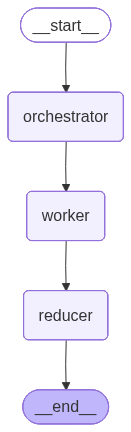

In [37]:
from agent.graph import build_graph
from IPython.display import Image

graph = build_graph()   # ✅ create graph object

Image(graph.get_graph().draw_mermaid_png())

In [38]:
from agent.graph import build_graph

graph = build_graph()

response = graph.invoke({
    "query": "which product has highest revenue",
    "schema": schema
})

print(response)


🧠 Planned Steps:
 Here are the steps to break down the query:

**1. Identify the Goal**
The goal is to find the product with the highest revenue.

**2. Determine the Data Source**
Identify the database or data source that contains the product revenue data.

**3. Choose the Relevant Table**
Select the table that contains the product revenue data. This table is likely to be named something like "products", "sales", or "revenue".

**4. Define the Revenue Column**
Identify the column in the table that contains the revenue data. This column is likely to be named something like "revenue", "sales", or "amount".

**5. Filter Out Non-Relevant Data**
Filter out any rows in the table that do not contain revenue data or are not relevant to the query.

**6. Group the Data by Product**
Group the remaining data by the product ID or name.

**7. Calculate the Total Revenue for Each Product**
Calculate the total revenue for each product by summing up the revenue values in each group.

**8. Find the Pro

# Database data creation


In [52]:
import pandas as pd
import numpy as np
import random
from faker import Faker
from datetime import datetime, timedelta

In [53]:
fake = Faker()

NUM_ROWS = 100000

In [54]:
products = {

    "Laptop": {
        "category": "Electronics",
        "sub_category": "Computers",
        "brand": ["Dell", "HP", "Lenovo", "Apple"],
        "price_range": (500, 2500)
    },

    "Phone": {
        "category": "Electronics",
        "sub_category": "Mobiles",
        "brand": ["Apple", "Samsung", "Xiaomi"],
        "price_range": (200, 1800)
    },

    "Chair": {
        "category": "Furniture",
        "sub_category": "Home Furniture",
        "brand": ["IKEA", "Nilkamal"],
        "price_range": (50, 500)
    },

    "Shoes": {
        "category": "Fashion",
        "sub_category": "Footwear",
        "brand": ["Nike", "Adidas", "Puma"],
        "price_range": (30, 300)
    },

    "Watch": {
        "category": "Fashion",
        "sub_category": "Accessories",
        "brand": ["Casio", "Titan", "Rolex"],
        "price_range": (50, 5000)
    }

}

In [70]:
from database.db import get_connection
import pandas as pd

conn = get_connection()

query = """
SELECT COUNT(*) as total_rows
FROM marketing_sales
"""

df = pd.read_sql(query, conn)

df

/var/folders/3l/mv638r2x5ld330h57fl8k9h40000gn/T/ipykernel_2862/725676697.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,total_rows
0,4572


In [66]:
from retrievers.schema_retriever import retrieve_relevant_schema


query = "top profitable brands"

results = retrieve_relevant_schema(query)

for result in results:

    print("\n====================")
    print(result)


{'table': 'sales', 'text': '\n        Table: sales\n\n        Columns:\n        sale_id (int), order_id (varchar), sale_date (date), customer_id (int), customer_name (varchar), customer_age (int), customer_gender (varchar), city (varchar), region (varchar), country (varchar), product_id (int), product_name (varchar), category (varchar), sub_category (varchar), brand (varchar), unit_price (float), cost_price (float), quantity (int), discount_percent (float), tax_percent (float), shipping_cost (float), payment_method (varchar), sales_channel (varchar), customer_segment (varchar), rating (float), returned (tinyint), delivery_days (int), stock_available (int), warehouse_location (varchar)\n        '}


In [67]:
df=pd.read_csv("/Users/prakashsah/text2sql-agent/Dummy Data HSS.csv")

In [68]:
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

# -----------------------------------
# Database Credentials
# -----------------------------------
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")


# -----------------------------------
# Create SQLAlchemy Engine
# -----------------------------------
engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}"
)


# -----------------------------------
# Append DataFrame to Existing Table
# -----------------------------------
df.to_sql(
    name="marketing_sales",   # table name
    con=engine,
    if_exists="append",       # append rows
    index=False,
    chunksize=5000,
    method="multi"
)

print("Data appended successfully!")

Data appended successfully!


In [72]:
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

load_dotenv()


# -----------------------------------
# DB Credentials
# -----------------------------------
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")


# -----------------------------------
# Create Engine
# -----------------------------------
engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}"
)


# -----------------------------------
# Show Tables
# -----------------------------------
with engine.connect() as conn:

    tables_result = conn.execute(
        text("SHOW TABLES")
    )

    tables = tables_result.fetchall()


    print("\n" + "=" * 70)
    print("DATABASE TABLES")
    print("=" * 70)


    for table in tables:

        table_name = table[0]

        print(f"\n\nTABLE: {table_name}")
        print("-" * 70)


        # -----------------------------------
        # Columns
        # -----------------------------------
        columns_result = conn.execute(

            text(f"DESCRIBE {table_name}")

        )

        columns = columns_result.fetchall()


        print("\nCOLUMNS:\n")

        for col in columns:

            print(
                f"{col[0]} ({col[1]})"
            )


        # -----------------------------------
        # Row Count
        # -----------------------------------
        count_result = conn.execute(

            text(
                f"SELECT COUNT(*) FROM {table_name}"
            )

        )

        row_count = count_result.fetchone()[0]

        print(f"\nTOTAL ROWS: {row_count}")


DATABASE TABLES


TABLE: customers
----------------------------------------------------------------------

COLUMNS:

customer_id (int)
customer_name (varchar(255))
customer_age (int)
customer_gender (varchar(50))
city (varchar(100))
region (varchar(100))
country (varchar(100))
customer_segment (varchar(100))

TOTAL ROWS: 0


TABLE: marketing_sales
----------------------------------------------------------------------

COLUMNS:

TV (double)
Radio (double)
Social Media (double)
Influencer (text)
Sales (double)

TOTAL ROWS: 4572


TABLE: products
----------------------------------------------------------------------

COLUMNS:

product_id (int)
product_name (varchar(255))
category (varchar(100))
sub_category (varchar(100))
brand (varchar(100))
unit_price (float)
cost_price (float)

TOTAL ROWS: 0


TABLE: sales
----------------------------------------------------------------------

COLUMNS:

sale_id (int)
order_id (varchar(255))
sale_date (date)
customer_id (int)
product_id (int)
quantity 